In [2]:
import numpy as np
import pandas as pd
import xarray as xr

%matplotlib inline
import matplotlib.pyplot as plt

import cartopy.crs as ccrs
import cartopy.feature as cfeature

from matplotlib import colors
from matplotlib.patches import Rectangle
from matplotlib.tri import Triangulation

from copy import copy

In [2]:
grid_data = {}

# Grid info for deterministic runs:xr.open_dataset("./grids/icon_grid_0026_R03B07_G.nc")
grid_data["grid_det"] = xr.open_dataset("./grids/icon_grid_0026_R03B07_G.nc") 
grid_data["tri_det"] = Triangulation(np.rad2deg(grid_data["grid_det"]["clon"]), np.rad2deg(grid_data["grid_det"]["clat"]))
grid_data["area_det"] = grid_data["grid_det"]["cell_area"]#in m^2 although mislabeld as steradian

# Grid info for ensemble runs:
grid_data["grid_ens"] = xr.open_dataset("./grids/icon_grid_0028_R02B07_N02.nc")
grid_data["tri_ens"] = Triangulation(np.rad2deg(grid_data["grid_ens"]["clon"]), np.rad2deg(grid_data["grid_ens"]["clat"]))
grid_data["area_ens"] = grid_data["grid_ens"]["cell_area"]


# Define "study area"
x0, y0 = 2, 47
wx, wy = 8, 6.5

grid_data["cells_det"] = ((np.rad2deg(grid_data["grid_det"]["clon"]) >= x0) & (np.rad2deg(grid_data["grid_det"]["clon"]) <= (x0+wx)) & 
                          (np.rad2deg(grid_data["grid_det"]["clat"]) >= y0) & (np.rad2deg(grid_data["grid_det"]["clat"]) <= (y0+wy))).values

grid_data["cells_ens"] = ((np.rad2deg(grid_data["grid_ens"]["clon"]) >= x0) & (np.rad2deg(grid_data["grid_ens"]["clon"]) <= (x0+wx)) & 
                          (np.rad2deg(grid_data["grid_ens"]["clat"]) >= y0) & (np.rad2deg(grid_data["grid_ens"]["clat"]) <= (y0+wy))).values

In [3]:
# Plotting setup:
lvls = [0,0.1,1,2,5,10,15,20,30,50,75,100,125,150,200]
norm = colors.BoundaryNorm(lvls, 256)

# Deterministic

In [ ]:
def read_var_det(var, dts, data_dir):
    # The merged files contain all time steps, i.e., step, step- 1/2/3. Therefore doing diff works "out of the box".
    fnames = [f"{data_dir}/fc_R03B07_tp_merged.{dt.year:02}{dt.month:02}{dt.day:02}{dt.hour:02}" for dt in dts]

    datasets = []
    for fname in fnames:
        dataset = xr.open_dataset(fname, engine="cfgrib").rename({"values": "cell"})[var]
        dataset = dataset.diff(dim="step")
        dataset["step"] = dataset["valid_time"]
        datasets.append(dataset)

    return xr.concat(datasets, dim="step")

In [75]:
dts = pd.date_range(start="2021-07-10T00", end="2021-07-15T00", freq="3h")

base_dir = "/automount/agh/s6tifohr/july21_eval/data"

exp_name = "REA"
da_rea = read_var_det("tp", dts, f"{base_dir}/{exp_name}/merged/tp")

exp_name = "BLK_CTL"
da_ctl = read_var_det("tp", dts, f"{base_dir}/{exp_name}/merged/tp")

exp_name = "BLK_WLT"
da_wlt = read_var_det("tp", dts, f"{base_dir}/{exp_name}/merged/tp")

exp_name = "BLK_SAT"
da_sat = read_var_det("tp", dts, f"{base_dir}/{exp_name}/merged/tp")

ecCodes provides no latitudes/longitudes for gridType='unstructured_grid'


In [ ]:
grid = xr.open_dataset("./grids/icon_grid_0026_R03B07_G.nc")
mask = (np.rad2deg(grid["clon"].values) >= -120) & (np.rad2deg(grid["clon"].values) <= 90) & (np.rad2deg(grid["clat"].values) >= 0) # mask domain of cut data
lons, lats = np.rad2deg(grid["clon"][mask]), np.rad2deg(grid["clat"][mask])
mask_region = (lons >= -5) & (lons <= 25) & (lats >= 37) & (lats <= 62) # mask an area over central Euorpe
mask_focus = (lons >= x0) & (lons <= (x0+wx)) & (lats >= y0) & (lats <= (y0+wy)) # mask the impacted focus region
ii_focus = np.arange(860142)[mask_focus]

## 48h Precipitation Sums

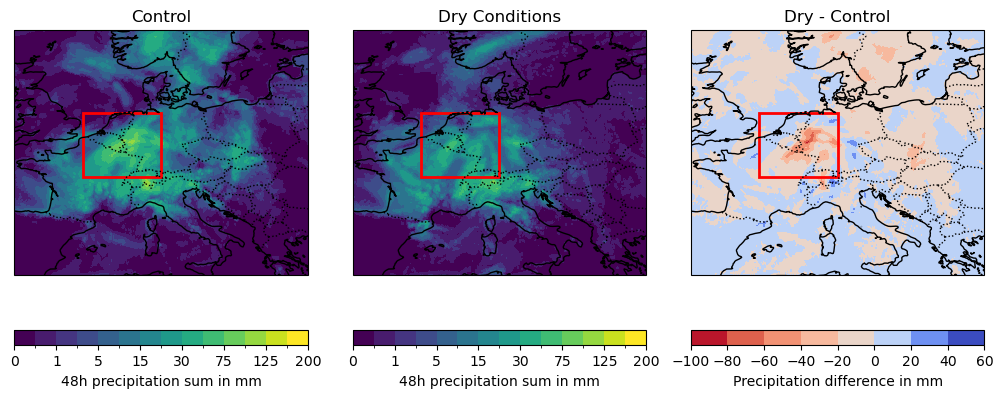

In [53]:
fig, axs = plt.subplots(1, 3, figsize=(10,4), subplot_kw={'projection': ccrs.PlateCarree()})
fig.tight_layout(w_pad=3.2)

im = axs[0].tricontourf(lons, lats, da_ctl.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step"), levels=lvls, norm=norm)
plt.colorbar(im, ax=axs[0], location="bottom", label="48h precipitation sum in mm")
axs[0].set(title="Control")

im = axs[1].tricontourf(lons, lats, da_wlt.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step"), levels=lvls, norm=norm)
plt.colorbar(im, ax=axs[1], location="bottom", label="48h precipitation sum in mm")
axs[1].set(title="Dry Conditions")

diff = da_wlt.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step") - da_ctl.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step")
diff.data[~mask_region] = 0.
divnorm = colors.TwoSlopeNorm(vmin=np.nanmin(diff.values), vcenter=0, vmax=np.nanmax(diff.values))
im = axs[2].tricontourf(lons, lats, diff, norm=divnorm, cmap="coolwarm_r")
plt.colorbar(im, ax=axs[2], location="bottom", label="Precipitation difference in mm")
axs[2].set(title="Dry - Control")

for ax in axs:
    ax.set_extent([-5, 25, 37, 62], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Create a Rectangle patch
    rectangle = Rectangle((x0, y0), wx, wy, edgecolor='red', linewidth=2, fill=False)
    ax.add_patch(rectangle)

plt.savefig(f'./figs/map_comp_48h_ctl_dry.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

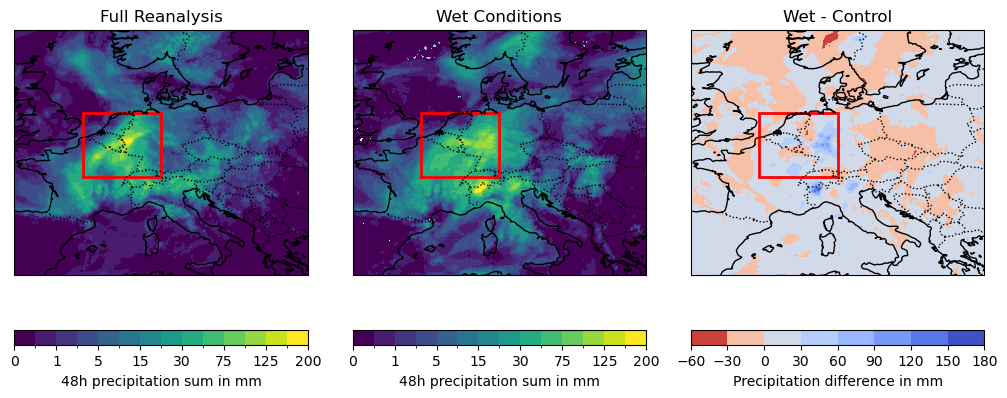

In [82]:
fig, axs = plt.subplots(1, 3, figsize=(10,4), subplot_kw={'projection': ccrs.PlateCarree()})
fig.tight_layout(w_pad=3.2)

im = axs[0].tricontourf(grid_data["tri_det"], da_rea.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step"), levels=lvls, norm=norm)
#im = axs[0].tricontourf(lons, lats, da_ctl.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step"), levels=lvls, norm=norm)
plt.colorbar(im, ax=axs[0], location="bottom", label="48h precipitation sum in mm")
axs[0].set(title="Full Reanalysis")

im = axs[1].tricontourf(lons, lats, da_sat.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step"), levels=lvls, norm=norm)
plt.colorbar(im, ax=axs[1], location="bottom", label="48h precipitation sum in mm")
axs[1].set(title="Wet Conditions")

diff = da_sat.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step") - da_ctl.sel(step=slice(np.datetime64("2021-07-13"), np.datetime64("2021-07-15"))).sum(dim="step")
diff.data[~mask_region] = 0.
divnorm = colors.TwoSlopeNorm(vmin=np.nanmin(diff.values), vcenter=0, vmax=np.nanmax(diff.values))
im = axs[2].tricontourf(lons, lats, diff, norm=divnorm, cmap="coolwarm_r")
plt.colorbar(im, ax=axs[2], location="bottom", label="Precipitation difference in mm")
axs[2].set(title="Wet - Control")

for ax in axs:
    ax.set_extent([-5, 25, 37, 62], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)
    ax.add_feature(cfeature.BORDERS, linestyle=':')

    # Create a Rectangle patch
    rectangle = Rectangle((x0, y0), wx, wy, edgecolor='red', linewidth=2, fill=False)
    ax.add_patch(rectangle)

plt.savefig(f'./figs/map_comp_48h_rea_wet.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

## Time Series

In [45]:
ds_rea = xr.open_dataset("./data/REA/TOT_PREC_rea.nc")["TOT_PREC"]
ts_rea = (ds_rea * grid_data[f"area_det"].data).isel(ncells=grid_data[f"cells_det"]).sum(dim="ncells")

In [66]:
ds_rea.isel(ncells=grid_data[f"cells_det"])

<xarray.DataArray 'TOT_PREC' (time: 97, ncells: 2293)> Size: 890kB
array([[0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
       [0.007812, 0.042969, 0.150391, ..., 0.150391, 0.224609, 0.099609],
       [0.292969, 0.296875, 0.226562, ..., 0.378906, 0.359375, 0.371094],
       ...,
       [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
       [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ],
       [0.      , 0.      , 0.      , ..., 0.      , 0.      , 0.      ]],
      dtype=float32)
Coordinates:
  * time     (time) datetime64[ns] 776B 2021-07-05 ... 2021-07-17
Dimensions without coordinates: ncells
Attributes:
    long_name:                    Total Precipitation (Accumulation)
    units:                        kg m-2
    param:                        52.1.0
    CDI_grid_type:                unstructured
    number_of_grid_in_reference:  1

In [68]:
da_sat.sel(cell=ii_focus)

<xarray.DataArray 'tp' (step: 123, cell: 2293)> Size: 1MB
array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)
Coordinates:
    time        (step) datetime64[ns] 984B 2021-07-09T21:00:00 ... 2021-07-14...
    surface     float64 8B 0.0
    valid_time  (step) datetime64[ns] 984B 2021-07-09T22:00:00 ... 2021-07-15
  * step        (step) datetime64[ns] 984B 2021-07-09T22:00:00 ... 2021-07-15
Dimensions without coordinates: cell

In [90]:
cell_areas_focus = grid_data["area_det"].sel(cell=np.arange(2949120)[mask])
ts_ctl = (da_ctl * cell_areas_focus).sel(cell=ii_focus).sum(dim="cell")
ts_wlt = (da_wlt * cell_areas_focus).sel(cell=ii_focus).sum(dim="cell")
ts_sat = (da_sat * cell_areas_focus).sel(cell=ii_focus).sum(dim="cell")

ts_rea = (da_rea * grid_data["area_det"]).sel(cell=grid_data["cells_det"]).sum(dim="cell")

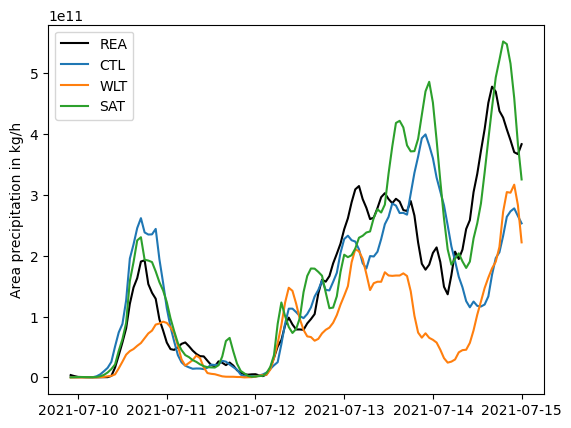

In [93]:
fig, ax = plt.subplots()

ax.plot(ts_rea["valid_time"], ts_rea, label="REA", color="black")
ax.plot(ts_ctl["valid_time"], ts_ctl, label="CTL")
ax.plot(ts_wlt["valid_time"], ts_wlt, label="WLT")
ax.plot(ts_sat["valid_time"], ts_sat, label="SAT")

plt.legend()

ax.set(ylabel="Area precipitation in kg/h")

plt.savefig(f'./figs/experiment_ts.png', dpi=300, bbox_inches='tight', format='png')
plt.show()

# Ensemble

In [ ]:
def read_var_det_ens(var, dts, data_dir):
    for mem in range(1,21):
        fnames = [f"{data_dir}/fc_R02B06_tp_merged.{dt.year:02}{dt.month:02}{dt.day:02}{dt.hour:02}" for dt in dts]

    datasets = []
    for fname in fnames:
        dataset = xr.open_dataset(fname, engine="cfgrib").rename({"values": "cell"})[var]
        dataset = dataset.diff(dim="step")
        dataset["step"] = dataset["valid_time"]
        datasets.append(dataset)

    return xr.concat(datasets, dim="step")

# Assimilation Region Showcase

In [13]:
da_rea = xr.open_dataset("data/REA/merged_t2m.grb")["t2m"]

Ignoring index file 'data/REA/merged_t2m.grb.5b7b6.idx' incompatible with GRIB file


In [ ]:
# This is not actually coinciding with the passive region, which is -10 to 40E and 30 to 75N, 
# but I used it to get a background in the image below  
mask_passive_region = ((np.rad2deg(grid_data["grid_det"]["clon"]) >= -20) & (np.rad2deg(grid_data["grid_det"]["clon"]) <= 50) & 
                       (np.rad2deg(grid_data["grid_det"]["clat"]) >= 20) & (np.rad2deg(grid_data["grid_det"]["clat"]) <= 85)).values
lons_pr, lats_pr = np.rad2deg(grid_data["grid_det"]["clon"][mask_passive_region]), np.rad2deg(grid_data["grid_det"]["clat"][mask_passive_region])

ii_passive_region = np.arange(len(mask_passive_region))[mask_passive_region]

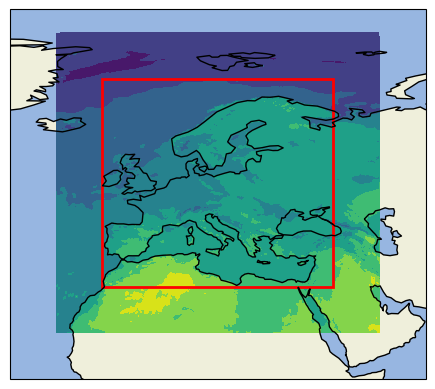

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-20, 50, 20, 85], crs=ccrs.PlateCarree())

im = ax.tricontourf(lons_pr, lats_pr, da_rea.isel(time=4, values=ii_passive_region))

# Create a Rectangle patch for the passive observation region:
rectangle = Rectangle((-10, 30), 50, 45, edgecolor='red', linewidth=2, fill=False)
ax.add_patch(rectangle)

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

#plt.colorbar(im)
plt.show()

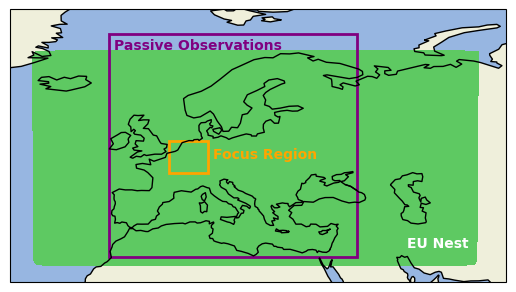

In [ ]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([-30, 70, 25, 80], crs=ccrs.PlateCarree())

im = ax.tricontourf(grid_data["tri_ens"], np.zeros(len(grid_data["area_ens"])))
ax.text(50, 32, "EU Nest", color="white", weight="bold")

# Create a rectangle patch for the passive observation region:
box_passive = Rectangle((-10, 30), 50, 45, edgecolor="purple", linewidth=2, fill=False)
ax.add_patch(box_passive)
ax.text(-9, 72, "Passive Observations", color="purple", weight="bold")

# Create a rectangle patch for the focus region
box_focus = Rectangle((2, 47), 8, 6.5, edgecolor="orange", linewidth=2, fill=False)
ax.add_patch(box_focus)
ax.text(11, 50, "Focus Region", color="orange", weight="bold")

ax.add_feature(cfeature.LAND)
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.COASTLINE)

plt.savefig("figs/demo_nest_passive_obs.png", dpi=300, bbox_inches='tight', format='png')
plt.show()

# Map

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(10,4), subplot_kw={'projection': ccrs.PlateCarree()})
fig.tight_layout(w_pad=2)

# Plot of data A:
im = axs[0].tricontourf(grid_data["tri_mask"], data_a, levels=lvls, norm=norm)
plt.colorbar(im, ax=axs[0], location="bottom", label="48h Precipitation Sum / mm", shrink=0.95)
axs[0].set(title=title_a)

# Plot of data B:
im = axs[1].tricontourf(grid_data["tri_mask"], data_b, levels=lvls, norm=norm)
plt.colorbar(im, ax=axs[1], location="bottom", label="48h Precipitation Sum / mm", shrink=0.95)
axs[1].set(title=title_b)

# Difference plot:
divnorm = colors.TwoSlopeNorm(vmin=np.nanmin(diff), vcenter=0, vmax=np.nanmax(diff))
im = axs[2].tricontourf(grid_data["tri_mask"], diff, norm=divnorm, cmap="coolwarm")
cbar = plt.colorbar(im, ax=axs[2], location="bottom", label="Difference / mm", shrink=0.95)
cbar.set_ticks([-120, -80, -40, 0, 40])
axs[2].set(title=title_diff)

# Add coastlines:
for ax in axs:
    ax.set_extent([-5, 25, 37, 62], crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.LAND)
    ax.add_feature(cfeature.OCEAN)
    ax.add_feature(cfeature.COASTLINE)

# Create a Rectangle patch:
for ax in axs:
    rectangle = Rectangle((x0, y0), wx, wy, edgecolor='red', linewidth=2, fill=False)
    ax.add_patch(rectangle)

plt.show()

# Timeseries


# LARSIM

## Disaggregate the 3h accumulated variables

In [3]:
def diff_within_blocks_vectorized(da, block_size=3):
    """
    Vectorized version using groupby.
    """
    # Create block labels for grouping
    time_index = np.arange(len(da.time))
    block_labels = np.ceil(time_index / 3).astype(int)
    
    # Add block labels as a coordinate
    da_with_blocks = da.assign_coords(block=('time', block_labels))
    
    # Define a function to apply to each block
    def block_diff(block):
        if len(block.time) > 1:
            # Create a mask for all positions except the first in each block
            time_pos = xr.DataArray(range(len(block.time)), dims=['time'], coords={'time': block.time})
            mask = time_pos > 0
            
            # Shift the block by one position along time
            shifted = block.shift(time=1)
            
            # Use where to apply the difference only where mask is True
            return block.where(~mask, block - shifted)
        return block
    
    # Apply the function to each block and concatenate results
    result = da_with_blocks.groupby('block').map(block_diff)
    
    # Remove the block coordinate
    result = result.drop_vars('block')
    
    return result

In [22]:
path_data = "/automount/agh/s6tifohr/july21_eval/data/LARSIM/"
exp_name = "blcklst_sat"
ds = xr.open_mfdataset([f"{path_data}/{exp_name}/daily_files/fc_R03B08_N02_sel.202107{dd:02}.nc" for dd in range(6,17)])

In [23]:
# Disaggregate grid scale rain
da_diff_rain_gsp = diff_within_blocks_vectorized(ds["RAIN_GSP"])
ds["RAIN_GSP"] = da_diff_rain_gsp

# Disaggregate total precipitation
da_diff_tot_prec = diff_within_blocks_vectorized(ds["TOT_PREC"])
ds["TOT_PREC"] = da_diff_tot_prec

In [25]:
# Output daily files:
for dd in range(6,17):
    time_slice = slice(np.datetime64(f"2021-07-{dd:02}T00"), np.datetime64(f"2021-07-{dd:02}T23"))
    path_out = f"{path_data}/{exp_name}/disaggregated/larsim_{exp_name}_det_202107{dd:02}.nc"
    ds.sel(time=time_slice).to_netcdf(path_out)